# Laboratorium 09 — Explainable AI (XAI) dla klasyfikacji komórek krwi

W tym laboratorium poznamy **metody wyjaśnialności modeli głębokich (Explainable AI, XAI)** na przykładzie prostego modelu klasyfikacji obrazów medycznych. Skupimy się na **wizualizacji tego, na co patrzy model**, gdy podejmuje decyzję.

**Cele:**
- zaimplementować prostą sieć CNN do klasyfikacji komórek krwii na zdjęciach mikroskopowych,
- wygenerować **mapy saliency (gradientowe)**,
- zaimplementować i zastosować **Grad-CAM**,
- nauczyć się interpretować heatmapy: czy model patrzy na obszar anatomicznie sensowny,
- spróbować zmienić interpretację sieci (adversarial attack).

**Dataset:** `BloodMNIST` ze zbioru **MedMNIST** — zestaw obrazów mikroskopowych komórek krwi (8 klas różnych typów komórek). Dataset zawiera następujące typy komórek krwi:

0. Basophil
1. Eosinophil
2. Erythroblast
3. Immature Granulocytes (IG)
4. Lymphocyte
5. Monocyte
6. Neutrophil
7. Platelet


## 0. Importy i konfiguracja

In [1]:
import os
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import torchvision.transforms as transforms

import pytorch_lightning as pl
from pytorch_lightning import LightningModule, LightningDataModule, Trainer
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from torchmetrics.classification import Accuracy, AUROC

import medmnist
from medmnist import INFO

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision('medium')

/home/patryk/Desktop/venv/ML_venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Zadanie 1: Implementacja DataModule

Stwórz klasę `PneumoniaDataModule` dziedziczącą po `LightningDataModule`, która będzie odpowiadać za wczytywanie danych z datasetu BloodMNIST. Możesz wzorować się na modułąch implementowanych w ramach wcześniejszych laboratoriów. Wczytaj dane kolorowe w formacie RGB (argument `as_rgb=True`).

Sprawdź rozmiar wczytywanych batchy.

In [2]:
DATA_FLAG = 'bloodmnist'
DOWNLOAD_ROOT = '/home/patryk/Desktop/AiR_ISS/sem2/PIAOM/lab9'

info = INFO[DATA_FLAG]
n_classes = len(info['label'])

print('Dataset:', info['description'])
print('Liczba klas:', n_classes)
print('Etykiety:', info['label'])


Dataset: The BloodMNIST is based on a dataset of individual normal cells, captured from individuals without infection, hematologic or oncologic disease and free of any pharmacologic treatment at the moment of blood collection. It contains a total of 17,092 images and is organized into 8 classes. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images with resolution 3×360×363 pixels are center-cropped into 3×200×200, and then resized into 3×28×28.
Liczba klas: 8
Etykiety: {'0': 'basophil', '1': 'eosinophil', '2': 'erythroblast', '3': 'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)', '4': 'lymphocyte', '5': 'monocyte', '6': 'neutrophil', '7': 'platelet'}


In [3]:
from medmnist import BloodMNIST

train_dataset = BloodMNIST(
    split='train',
    download=True,
    root=DOWNLOAD_ROOT
)

test_dataset = BloodMNIST(
    split='test',
    download=True,
    root=DOWNLOAD_ROOT
)

val_dataset = BloodMNIST(
    split='val',
    download=True,
    root=DOWNLOAD_ROOT
)

print("Pobrano BloodMNIST!")
print("Liczba obrazów (train):", len(train_dataset))
print("Liczba obrazów (test):", len(test_dataset))
print("Liczba obrazów (val):", len(val_dataset))

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 35.5M/35.5M [00:03<00:00, 10.7MB/s]


Pobrano BloodMNIST!
Liczba obrazów (train): 11959
Liczba obrazów (test): 3421
Liczba obrazów (val): 1712


### Zadanie 2: Podgląd przykładowych obrazów

Wyświetl kilka przykładowych obrazów w przetwarzanym zbiorze razem z ich etykietami.

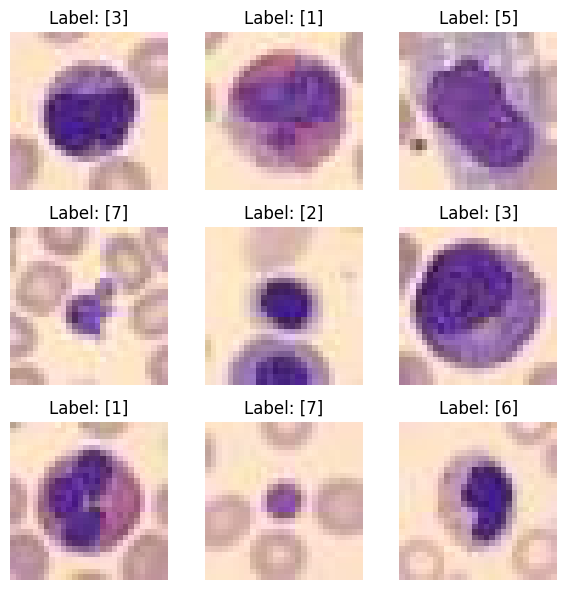

In [4]:
import random 

num_img = 9

n = int(np.sqrt(num_img))

fig, axes = plt.subplots(n, n, figsize=(6, 6))
axes = axes.flatten()

for i in range(n * n):
    rand_int = random.randint(0, len(train_dataset) - 1)
    
    img, label = train_dataset[rand_int] 
    
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Label: {label}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### Zadanie 3: Implementacja architektury CNN

**Klasa `SimpleCNN(nn.Module)`**

Zaimplementuj architekturę prostej sieci konwolucyjnej do zadania klasyfikacji. Niech zaprojektowana sieć ma około miliona parametrów.
Dla wykorzystywanego datasetu powinno to pozwolić na osiągnięcie powyżej 95% dokładności na zbiorze testowym. Możesz się wzorować na sieciach z wcześniejszych laboratoriów.

**Klasa `LightningSimpleCNN(LightningModule)`**

Podobnie jak we wcześniejszych ćwiczeniach, stwórz klasę dziedziczącą po `LightningModule`, która będzie zarządzać treningiem, jego parametrami i logować przebiej treningu.

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Block(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return F.relu(out)


class ResNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=8):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.block1 = Block(32, 32)        
        self.block2 = Block(32, 64, stride=2)  

        self.avg = nn.AdaptiveAvgPool2d((1, 1))

        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))

        x = self.block1(x)
        x = self.block2(x)

        x = self.avg(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

class LitResNet(pl.LightningModule):
	def __init__(self, model, lr=1e-3):
		super().__init__()
		self.model = model
		self.lr = lr

		self.loss_fn = nn.CrossEntropyLoss()
		self.train_acc = Accuracy(task="multiclass", num_classes=8)
		self.val_acc = Accuracy(task="multiclass", num_classes=8)
		self.test_acc = Accuracy(task="multiclass", num_classes=8)

	def forward(self, x):
		return self.model(x)

	def training_step(self, batch, batch_idx):
		x, y = batch
		logits = self(x)
		y = y.squeeze()
		loss = self.loss_fn(logits, y)

		self.train_acc.update(logits, y)
		self.log("train_loss", loss, prog_bar=True)
		self.log("train_acc", self.train_acc, prog_bar=True)

		return loss

	def validation_step(self, batch, batch_idx):
		x, y = batch
		logits = self(x)
		y = y.squeeze()
		loss = self.loss_fn(logits, y)

		self.val_acc.update(logits, y)
		self.log("val_loss", loss, prog_bar=True)
		self.log("val_acc", self.val_acc, prog_bar=True)
		
	def test_step(self, batch, batch_idx):
		x, y = batch
		logits = self(x)
		y = y.squeeze()
		loss = self.loss_fn(logits, y)
          
		self.test_acc.update(logits, y)
		self.log("val_loss", loss, prog_bar=True)
		self.log("val_acc", self.test_acc, prog_bar=True)

	def configure_optimizers(self):
		return torch.optim.Adam(self.parameters(), lr=self.lr)
    

class BloodMNISTDataModule(pl.LightningDataModule):
	def __init__(self, train_dataset, val_dataset, test_dataset, batch_size=32, num_workers=4):
		super().__init__()
		self.train_dataset = train_dataset
		self.val_dataset = val_dataset
		self.test_dataset = test_dataset
		self.batch_size = batch_size
		self.num_workers = num_workers

		self.transform = transforms.Compose([
			transforms.ToTensor()
		])

	def setup(self, stage=None):
		if hasattr(self.train_dataset, "transform"):
			self.train_dataset.transform = self.transform
		if hasattr(self.val_dataset, "transform"):
			self.val_dataset.transform = self.transform
			
		if hasattr(self.test_dataset, "transform"):
			self.test_dataset.transform = self.transform

	def train_dataloader(self):
		return DataLoader(
			self.train_dataset,
			batch_size=self.batch_size,
			shuffle=True,
			num_workers=self.num_workers,
			pin_memory=True
		)

	def val_dataloader(self):
		return DataLoader(
			self.val_dataset,
			batch_size=self.batch_size,
			shuffle=False,
			num_workers=self.num_workers,
			pin_memory=True
		)

	def test_dataloader(self):
		return DataLoader(
			self.test_dataset,
			batch_size=self.batch_size,
			shuffle=False,
			num_workers=self.num_workers,
			pin_memory=True
		)

### Zadanie 4: Trening modelu

Przeprowadź trening zdefiniowanego modelu. Pamiętaj, żeby zapisywać model o njalepszym wyniku na zbiorze walidacyjnym.

In [6]:
model = ResNet(in_channels=3, num_classes=8)
lit_model = LitResNet(model, lr=1e-3)

dm = BloodMNISTDataModule(train_dataset, val_dataset, test_dataset, batch_size=32, num_workers=4)

dm.setup()

trainer = pl.Trainer(
    max_epochs=10,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1
)

trainer.fit(lit_model, dm)


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/patryk/Desktop/venv/ML_venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode 
-------------------------------------

Epoch 9: 100%|███████████████████████████████████████████████| 374/374 [00:04<00:00, 77.37it/s, v_num=0, train_loss=0.0714, val_loss=1.780, val_acc=0.752]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|███████████████████████████████████████████████| 374/374 [00:04<00:00, 77.07it/s, v_num=0, train_loss=0.0714, val_loss=1.780, val_acc=0.752]


### Zadanie 5: Test najlepszego modelu

Wczytaj najlepszy model i przeprowadź jego ewaluację na zbiorze testowym.

In [7]:
trainer.test(lit_model, dm)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing DataLoader 0: 100%|████████████████████████████████████████████████████████████████████████████████████████████| 107/107 [00:00<00:00, 157.77it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          val_acc          │    0.7483192086219788     │
│         val_loss          │    1.8256746530532837     │
└───────────────────────────┴───────────────────────────┘

[{'val_loss': 1.8256746530532837, 'val_acc': 0.7483192086219788}]

## Explainable AI — wprowadzenie

W kontekście sieci CNN do klasyfikacji obrazów medycznych chcemy odpowiedzieć na pytanie:

> **Które piksele/regiony obrazu najbardziej wpływają na decyzję modelu?**

**Dlaczego XAI jest ważne w medycynie?**
- Trzeba rozumieć, dlaczego model podjął daną decyzję
- Wykrywanie błędnych wzorców (np. model patrzy na znaczniki zamiast na tkankę)
- Model może nauczyć się cech, których nie byliśmy świadomi
- Wymogi prawne dotyczące wyjaśnialności systemów AI w medycynie

### Saliency Maps (mapy czułości)
**Idea:** Gradient wyjścia względem wejścia pokazuje, które piksele najbardziej wpływają na predykcję.

**Matematyka:**
$$\text{Saliency}(x) = \left|\frac{\partial y_c}{\partial x}\right|$$

gdzie:
- $x$ — obraz wejściowy
- $y_c$ — logit/wyjście dla klasy $c$
- duża wartość gradientu → duży wpływ piksela na wynik

**Zalety:**
- Prosta implementacja
- Rozdzielczość odpowiada rozmiarowi wejścia
- Pokazuje lokalne zmiany

**Wady:**
- Może być zaszumiona
- Trudna do interpretacji w złożonych modelach
- Wrażliwa na małe perturbacje

### Grad-CAM (Gradient-weighted Class Activation Mapping)
**Idea:** Wykorzystuje gradienty względem **aktywacji ostatniej warstwy konwolucyjnej**, aby stworzyć mapę ciepła pokazującą, które regiony są ważne.

**Matematyka:**
$$\alpha_k = \frac{1}{Z}\sum_{i,j} \frac{\partial y_c}{\partial A^k_{ij}}$$
$$\text{Grad-CAM} = \text{ReLU}\left(\sum_k \alpha_k \cdot A^k\right)$$

gdzie:
- $A^k$ — aktywacje k-tego kanału ostatniej warstwy konwolucyjnej
- $\alpha_k$ — waga kanału k (średni gradient)
- ReLU — usuwamy negatywne wpływy

**Zalety:**
- Wyższa jakość wizualizacji (mniej szumu)
- Pokazuje regiony, nie pojedyncze piksele

**Wady:**
- Niższa rozdzielczość (wymaga interpolacji do wejściowego rozmiaru)
- Zależy od wyboru warstwy konwolucyjnej
- Może pomijać drobne detale

**Proces zastosowania XAI:**
1. Wybieramy obraz z zestawu walidacyjnego/testowego
2. Sprawdzamy predykcję modelu
3. Generujemy mapy saliency i Grad-CAM
4. Krytycznie interpretujemy czy model patrzy na prawidłowe cechy anatomiczne

### Zadanie 6: Pobranie danych do wizualizacji

In [8]:
val_loader = dm.val_dataloader()
val_batch = next(iter(val_loader))
val_images = val_batch[0].to(DEVICE)
val_labels = val_batch[1].long().view(-1).to(DEVICE)

val_images.shape, val_labels.shape

(torch.Size([32, 3, 28, 28]), torch.Size([32]))

### Zadanie 7: Mapa saliency

Stwórz funkcję `compute_saliency_map`.

1. Jej argumentami są: model (nauczona sieć), obraz wejściowy i ewentualną docelową klasę, względem której będzie sprawdzany gradient.
2. Ustaw model w tryb ewaluacji: `model.eval()`.
3. Włącz obliczanie gradientów dla obrazu: `image = image.to(DEVICE).requires_grad_(True)`.
4. Wyczyść gradienty (`model.zero_grad()`) oraz przepuść obraz przez sieć.
5. Jeśli nie została podana docelowa klasa jako argument, to wybierz klasę wyznaczoną przez sieć dla pierwszego elementu batcha: `logits.argmax(dim=1)[0].item()`.
6. Przypisz wynik sieci dla tej klasy (logit) do nowej zmiennej.
7. Wyznacz gradienty względem tego wyniku: `.backward()`.
8. Pobierz wartość bezwzględną gradientu wyniku względem obrazu wejściowego: `.grad.data.abs()`.
9. Oblicz normę L2 obliczonych gradientów względem kanałów obrazu wejściowego: `torch.norm`.
10. Dla wyniku wykonaj `.detach().cpu().numpy().squeeze()`. Zwróć otrzymaną wartość.
11. Funkcja `plot_saliency` do wizualizacji jest już zaimplementowana.
12. Poza funkcjami wybierz jeden obraz wejściowy: `val_images[idx:idx+1]` (zakres jest potrzebny, żeby zachować wymiar batcha), `val_labels[idx].item()`.
13. Wywołaj zaimplementowane funkcje dla tych danych.
14. Zinterpretuj wyniki.

**Jak interpretować wyniki?**
- Jasne/gorące obszary - piksele o dużym wpływie na decyzję
- Sprawdź czy model patrzy na komórkę czy na tło?
- Oceń czy wyróżnione obszary mają sens?

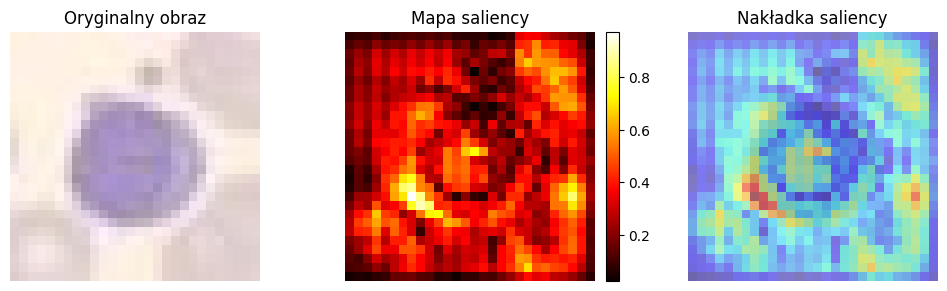

In [14]:
def compute_saliency_map(model, image, target_class=None):
    model.eval()
    model = model.to(DEVICE)

    image = image.to(DEVICE).requires_grad_(True)
    model.zero_grad()
    logits = model(image)
    if target_class is None:
        target_class = logits.argmax(dim=1)[0].item()
    score = logits[0, target_class]
    score.backward()
    grad = image.grad.data.abs()
    saliency = torch.norm(grad, p=2, dim=1)
    return saliency.detach().cpu().squeeze()

def plot_saliency(image, saliency):
    img = image.detach().cpu().numpy().squeeze()
    sal = saliency.detach().cpu().numpy().squeeze()

    img = img * 0.5 + 0.5
    img = np.clip(img, 0, 1)

    img = np.transpose(img, (1, 2, 0))

    fig, axs = plt.subplots(1, 3, figsize=(10, 3))
    axs[0].imshow(img)
    axs[0].set_title('Oryginalny obraz')
    axs[0].axis('off')

    im1 = axs[1].imshow(sal, cmap='hot')
    axs[1].set_title('Mapa saliency')
    axs[1].axis('off')
    plt.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)

    axs[2].imshow(img)
    axs[2].imshow(sal, cmap='jet', alpha=0.5)
    axs[2].set_title('Nakładka saliency')
    axs[2].axis('off')

    plt.tight_layout()
    plt.show()

model = model.to(DEVICE)

idx = 0
image = val_images[idx:idx+1]
label = val_labels[idx].item()

saliency = compute_saliency_map(model, image, target_class=None)
plot_saliency(image, saliency)

### Zadanie 8: Grad-CAM

1. Znajdź ostatnią warstwę konwolucyjną:

```
best_model_copy = copy.deepcopy(best_model)
conv_layers = [m for m in best_model_Copy.model.features.modules() if isinstance(m, nn.Conv2d)]
cam_layer = conv_layers[-1]
```

2. Przygotuj zmienne globalne:
- `global activation, gradients`
- `activation = None` — przechowa aktywacje z forward pass
- `gradients = None` — przechowa gradienty z backward pass|

3. Stwórz funkcję `forward_hook`:

```
def forward_hook(module, input, output):
    global activation
    activation = output
```

4. Stwórz funkcję `backward hook`:

```
def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]
```

5. Następnie zarejestruj te funkcje:

```
cam_layer.register_forward_hook(forward_hook)
cam_layer.register_full_backward_hook(backward_hook)
```

6. Zaimplementuj funkcję `compute_gradcam`:
  - Jej argumentami są: model (nauczona sieć), obraz wejściowy i ewentualną docelową klasę, względem której będzie sprawdzany gradient.
  - Ustaw model w tryb ewaluacji: `model.eval()`.
  - Włącz obliczanie gradientów dla obrazu: `image = image.to(DEVICE).requires_grad_(True)`.
  - Wyczyść gradienty (`model.zero_grad()`) oraz przepuść obraz przez sieć.
  - Jeśli nie została podana docelowa klasa jako argument, to wybierz klasę wyznaczoną przez sieć dla pierwszego elementu batcha: `logits.argmax(dim=1)[0].item()`.
  - Przypisz wynik sieci dla tej klasy (logit) do nowej zmiennej.
  - Wyznacz gradienty względem tego wyniku: `.backward()`.
  - Pobierz wartości globalnych zmiennych i sprawdź czy mają przypisane wartości (nie są `None`) oraz wykonaj dla nich `.detach()`.
  - Oblicz średni gradient dla każdego kanału: `weights = grad.mean(dim=[2, 3], keepdim=True)`.
  - Przemnóż aktywacje przez wagi i zsumuj względem kanałów: `cam = (weights * act).sum(dim=1, keepdim=True)`.
  - Następnie oblicz ReLU na podstawie wyjścia: `cam = F.relu(cam)`.
  - Usuń wymiar batcha i kanałów: `cam = cam[0, 0]`.
  - Znormalizuj zakres danych do [0; 1].

7. Funkcja do wyświetlenia wyniku `plot_gradcam` jest już zaimplementowana.

8. Elementy poza tymi funkcjami są takie same jak dla poprzedniego zadania (mapa saliency).

**Jak interpretować wyniki?**
- Czy model koncentruje się na komórce czy na tle?
- Czy podświetlone obszary odpowiadają charakterystycznym cechom danej klasy komórek?
- Czy model "patrzy" na artefakty obrazu (plamy, zniekształcenia)?

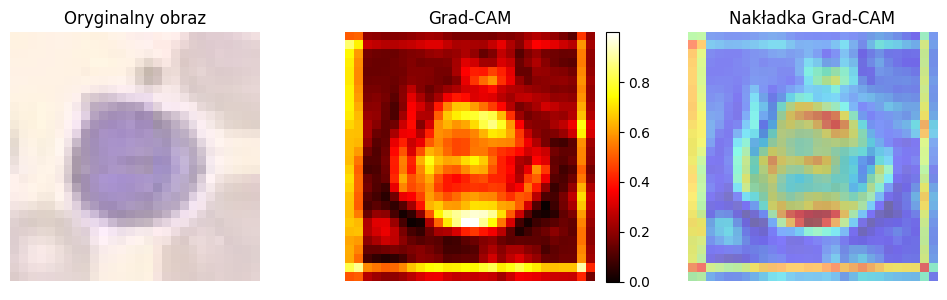

In [17]:
import copy
import torch.nn.functional as F

activation = None
gradients = None

def forward_hook(module, input, output):
    global activation, gradients
    activation = output
    gradients = None
    output.register_hook(lambda g: _save_grad(g))

def _save_grad(g):
    global gradients
    gradients = g

best_model_copy = model
cam_layer = best_model_copy.block1.conv1
cam_layer.register_forward_hook(forward_hook)

def compute_gradcam(model, image, target_class=None):
    global activation, gradients
    activation, gradients = None, None

    model.eval()
    model = model.to(DEVICE)

    image = image.to(DEVICE).requires_grad_(True)
    model.zero_grad()

    logits = model(image)
    if target_class is None:
        target_class = logits.argmax(dim=1)[0].item()

    score = logits[0, target_class]
    score.backward()

    act = activation
    grad = gradients

    if act is None or grad is None:
        raise RuntimeError("Brak activation/gradients — sprawdź czy forward_hook jest na właściwej warstwie.")

    act = act.detach()
    grad = grad.detach()

    weights = grad.mean(dim=[2, 3], keepdim=True)
    cam = (weights * act).sum(dim=1, keepdim=True)
    cam = F.relu(cam)
    cam = cam[0, 0]

    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    return cam.detach().cpu()

def plot_gradcam(image, cam):
    img = image.detach().cpu().numpy().squeeze()
    cam = cam.detach().cpu().numpy().squeeze()

    img = img * 0.5 + 0.5
    img = np.clip(img, 0, 1)
    img = np.transpose(img, (1, 2, 0))

    fig, axs = plt.subplots(1, 3, figsize=(10, 3))
    axs[0].imshow(img)
    axs[0].set_title('Oryginalny obraz')
    axs[0].axis('off')

    im1 = axs[1].imshow(cam, cmap='hot')
    axs[1].set_title('Grad-CAM')
    axs[1].axis('off')
    plt.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)

    axs[2].imshow(img)
    axs[2].imshow(cam, cmap='jet', alpha=0.5)
    axs[2].set_title('Nakładka Grad-CAM')
    axs[2].axis('off')

    plt.tight_layout()
    plt.show()

idx = 0
image = val_images[idx:idx+1]
cam = compute_gradcam(best_model_copy, image, target_class=None)
plot_gradcam(image, cam)

### Zadanie 9: Adversarial Attack — sprawdzenie odporności modelu

Adversarial example to obraz, który został nieznacznie zmodyfikowany w sposób, który jest niewidoczny dla człowieka, ale całkowicie zmienia predykcję modelu.

Dlaczego to ważne w medycynie?
- Testowanie odporności systemów AI
- Bezpieczeństwo: czy model jest podatny na manipulacje?
- Czy można ufać predykcjom w krytycznych przypadkach?

Rodzaje ataków:

Untargeted Attack - zmienia predykcję na dowolną inną klasę

Targeted Attack - zmienia predykcję na konkretną wybraną klasę

1. Zaimplementuj funkcję `create_adversarial_perturbation`:
  - Jej argumentami są: wytrenowany model, obraz wejściowy, prawdziwa klasa obrazu, maksymalna dozwolona modyfikacja (np. 0.15), learning rate dla optymalizacji (np. 0.01), liczba iteracji optymalizacji i opcjonalna klasa docelowa (w przypadku targeted attack).
  - Przełącz model w tryb ewaluacji.
  - Skopiuj obraz wejściowy: `original_image = image.clone().detach().to(DEVICE)`.
  - Stwórz macierz zmian obrazu: `torch.zeros_like(original_image, requires_grad=True, device=DEVICE)`.
  - Przygotuj optymalizator: `torch.optim.Adam([perturbation], lr=lr)`
  - Stwórz słownik do zapamiętania historii optymalizacji: `history = {'loss': [], 'pred_class': [], 'true_prob': [], 'perturbation_norm': []}`
  - Zaimplementuj pętlę optymalizacyjną:
    - Stwórz nowy obraz wejściowy (dodanie zmian do oryginalnego).
    - Obetnij wartości do zakresu [-1, 1].
    - Oblicz wyjście modelu.
    - Wyznacz prawdopodobieństwa klas za pomocą `torch.softmax(logits, dim=1)`.
    - W przypadku targeted attack strata to `F.cross_entropy(logits, torch.tensor([target_class], device=DEVICE))`.
    - W przypadku untargeted attack strata to `-F.cross_entropy(logits, torch.tensor([true_class], device=DEVICE))`.
    - Dodaj regularyzację do funkcji straty: `torch.mean(perturbation ** 2)` - ma spowodować, że modyfikacja będzie jak najmniejsza.
    - Obetnij zmieny do zakresu [-epsilon, epsilon] wewnątrz bloku `with torch.no_grad():`.
    - Sprawdź przewidywanie modelu dla zmodyfikowanego wejścia `.argmax(dim=1).item()`.
    - Zaktualizuj historię.
    - Na koniec pętli wykonaj iterację optymalziacji: `loss.backward()` i `optimizer.step()`.
  - Poza pętlą obetnij zmiany i wynikowy obraz do założonego zakresu (jak wcześniej).
  - Zwróć zmiany, zmodyfikowany obraz i historię.

  2. Funkcja do wizualizacji jest już zaimplementowana. Jej argumentami są: oryginalny obraz, zmodyfikowany obraz, modyfikację obrazu, prawdziwą klasę, oryginalne przewidywanie, zmodyfikowane przewidywanie, oryginalne prawdopodobieństwo, zmodyfikowane prawdopodobieństwo i historię.

  3. Wybierz próbkę, która została sklasyfikowana prawidłowo.

  ```
  for idx in range(len(val_images)):
    sample_image = val_images[idx:idx+1]
    true_label = val_labels[idx].item()
    
    with torch.no_grad():
        logits_orig = best_model(sample_image)
        pred_orig = logits_orig.argmax(dim=1).item()
    
    if pred_orig == true_label:
        print(f"Znaleziono próbkę {idx}: klasa {true_label}")
        break
  ```
  
  4. Sprawdź wynik modelu dla oryginalnych danych.

  ```
  with torch.no_grad():
    logits_orig = best_model(sample_image)
    probs_orig = torch.softmax(logits_orig, dim=1)
    prob_orig = probs_orig[0, pred_orig].item()
  ```

  5. Wykorzystaj zaimplementowaną funkcje do stworzenia zmodyfikowanego wejścia.

  6. Sprawdź wynik modelu dla zmodyfikowanego wejścia.

  ```
  with torch.no_grad():
    logits_adv = best_model(adv_image)
    probs_adv = torch.softmax(logits_adv, dim=1)
    pred_adv = logits_adv.argmax(dim=1).item()
    prob_adv = probs_adv[0, pred_adv].item()
  ```

  7. Zwizualizuj wynik za pomocą funkcji `visualize_adversarial_attack`.

  8. Wybierz konkretną klasę jako cel, wykonaj targeted attack i wyświetl wyniki.

  9. Poeksperymentuj z parametrami.

**Podsumowanie**
  - Czy model zmienił predykcję?
  - Po ilu iteracjach nastąpiła zmiana? (sprawdź wykresy)
  - Jaka jest końcowa pewność modelu?
  - Czy perturbacja jest widoczna gołym okiem na obrazie?
  - Czy różnica ×10 pokazuje strukturalne zmiany czy losowy szum?
  - Co oznacza podatność modelu na adversarial attacks dla zastosowań klinicznych?

**Zadania dodatkowe:** 
- Wygeneruj Grad-CAM dla adversarial image — na co teraz patrzy model?
- Porównaj saliency maps dla oryginalnego i adversarial obrazu

Znaleziono próbkę: 2 klasa: 7


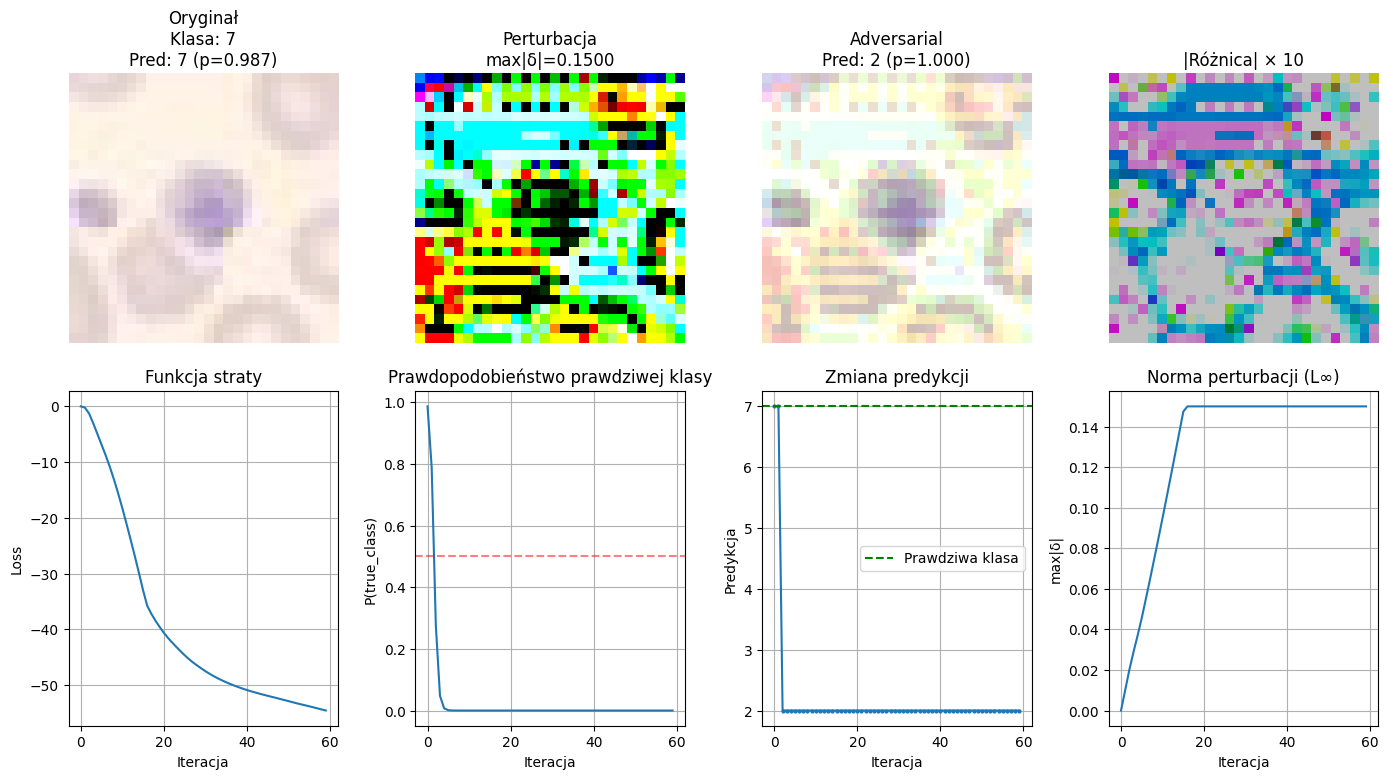

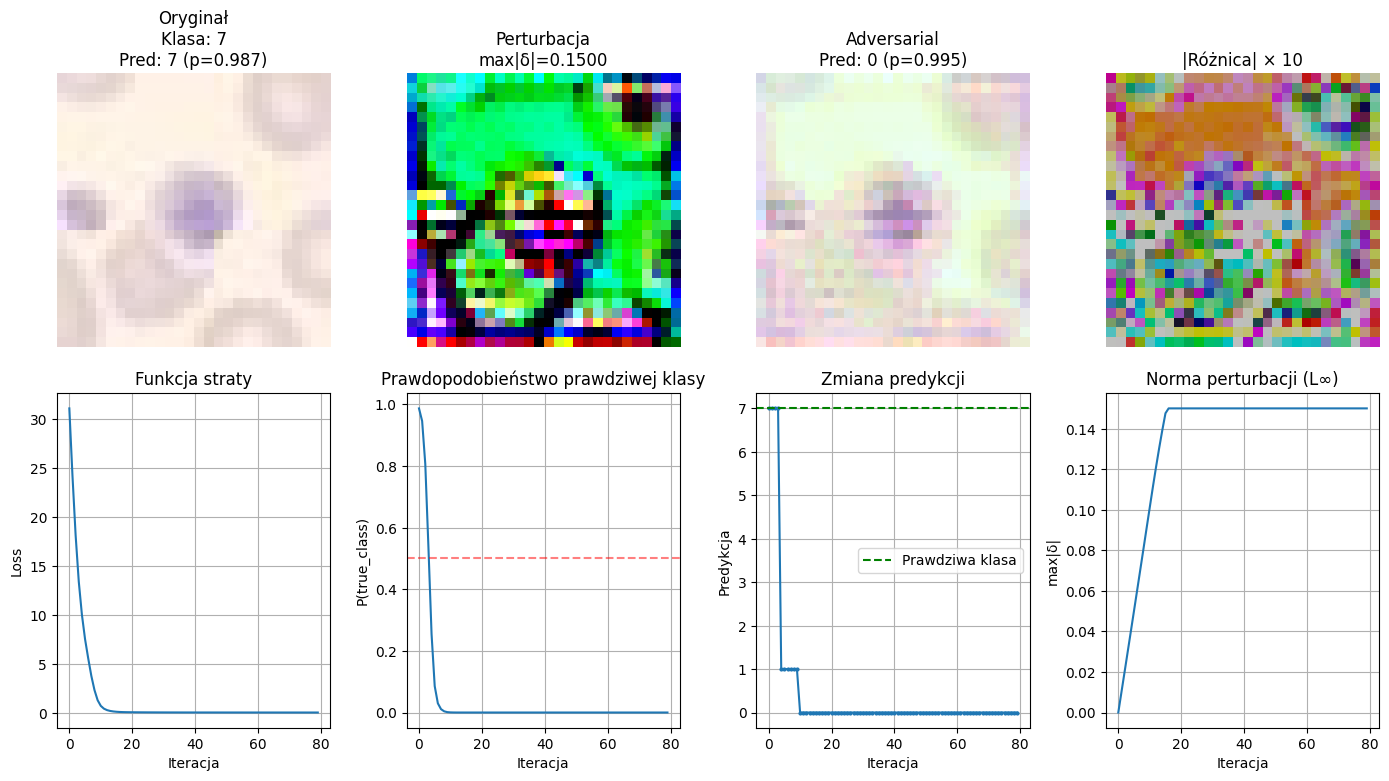

In [32]:
def create_adversarial_perturbation(model, image, true_class,
                                    epsilon=0.15, lr=0.01, iters=60,
                                    target_class=None):
    model.eval()
    model = model.to(DEVICE)

    # Przygotowanie obrazu z gradientem
    original_image = image.clone().detach().to(DEVICE)
    original_image.requires_grad = True

    perturbation = torch.zeros_like(original_image, requires_grad=True, device=DEVICE)
    optimizer = torch.optim.Adam([perturbation], lr=lr)

    history = {'loss': [], 'pred_class': [], 'true_prob': [], 'perturbation_norm': []}

    for _ in range(iters):
        adv_image = torch.clamp(original_image + perturbation, -1, 1)

        logits = model(adv_image)
        probs = torch.softmax(logits, dim=1)

        if target_class is None:
            loss_main = -F.cross_entropy(logits, torch.tensor([true_class], device=DEVICE))
        else:
            loss_main = F.cross_entropy(logits, torch.tensor([target_class], device=DEVICE))

        # Regularyzacja perturbacji
        loss_reg = torch.mean(perturbation ** 2)
        loss = loss_main + loss_reg

        pred = logits.argmax(dim=1).item()
        true_prob = probs[0, true_class].item()
        pert_inf = perturbation.detach().abs().max().item()

        history['loss'].append(loss.item())
        history['pred_class'].append(pred)
        history['true_prob'].append(true_prob)
        history['perturbation_norm'].append(pert_inf)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            perturbation.clamp_(-epsilon, epsilon)

    with torch.no_grad():
        perturbation = perturbation.clamp(-epsilon, epsilon)
        adv_image = torch.clamp(original_image + perturbation, -1, 1)

    return perturbation.detach(), adv_image.detach(), history


def visualize_adversarial_attack(original_image, adv_image, perturbation,
                                 true_class, pred_orig, pred_adv,
                                 prob_orig, prob_adv, history):

    fig = plt.figure(figsize=(14, 8))

    def denorm(img):
        img = img.detach().cpu().numpy().squeeze()
        img = img * 0.5 + 0.5  # jeśli dane były normalizowane do [-1,1]
        img = np.clip(img, 0, 1)
        return np.transpose(img, (1, 2, 0))

    orig_img = denorm(original_image)
    adv_img = denorm(adv_image)

    pert = perturbation.detach().cpu().numpy().squeeze()
    pert = np.transpose(pert, (1, 2, 0))

    ax1 = fig.add_subplot(2, 4, 1)
    ax1.imshow(orig_img)
    ax1.set_title(f'Oryginał\nKlasa: {true_class}\nPred: {pred_orig} (p={prob_orig:.3f})')
    ax1.axis('off')

    ax2 = fig.add_subplot(2, 4, 2)
    pert_vis = (pert - pert.min()) / (pert.max() - pert.min() + 1e-8)
    ax2.imshow(pert_vis)
    ax2.set_title(f'Perturbacja\nmax|δ|={np.abs(pert).max():.4f}')
    ax2.axis('off')

    ax3 = fig.add_subplot(2, 4, 3)
    ax3.imshow(adv_img)
    ax3.set_title(f'Adversarial\nPred: {pred_adv} (p={prob_adv:.3f})')
    ax3.axis('off')

    ax4 = fig.add_subplot(2, 4, 4)
    diff = np.abs(adv_img - orig_img) * 10
    diff = np.clip(diff, 0, 1)
    ax4.imshow(diff)
    ax4.set_title('|Różnica| × 10')
    ax4.axis('off')

    ax5 = fig.add_subplot(2, 4, 5)
    ax5.plot(history['loss'])
    ax5.set_xlabel('Iteracja')
    ax5.set_ylabel('Loss')
    ax5.set_title('Funkcja straty')
    ax5.grid(True)

    ax6 = fig.add_subplot(2, 4, 6)
    ax6.plot(history['true_prob'])
    ax6.axhline(y=0.5, color='r', linestyle='--', alpha=0.5)
    ax6.set_xlabel('Iteracja')
    ax6.set_ylabel('P(true_class)')
    ax6.set_title('Prawdopodobieństwo prawdziwej klasy')
    ax6.grid(True)

    ax7 = fig.add_subplot(2, 4, 7)
    ax7.plot(history['pred_class'], 'o-', markersize=2)
    ax7.axhline(y=true_class, color='g', linestyle='--', label='Prawdziwa klasa')
    ax7.set_xlabel('Iteracja')
    ax7.set_ylabel('Predykcja')
    ax7.set_title('Zmiana predykcji')
    ax7.legend()
    ax7.grid(True)

    ax8 = fig.add_subplot(2, 4, 8)
    ax8.plot(history['perturbation_norm'])
    ax8.set_xlabel('Iteracja')
    ax8.set_ylabel('max|δ|')
    ax8.set_title('Norma perturbacji (L∞)')
    ax8.grid(True)

    plt.tight_layout()
    plt.show()

best_model = model.to(DEVICE).eval()

val_loader = dm.val_dataloader()
val_images, val_labels = next(iter(val_loader))
val_images = val_images.to(DEVICE)
val_labels = val_labels.long().view(-1).to(DEVICE)

sample_image, true_label, pred_orig = None, None, None
for idx in range(len(val_images)):
    img = val_images[idx:idx+1]
    y = int(val_labels[idx].item())
    with torch.enable_grad():
        logits = best_model(img)
        pred = logits.argmax(dim=1).item()
    if pred == y:
        sample_image, true_label, pred_orig = img, y, pred
        print("Znaleziono próbkę:", idx, "klasa:", true_label)
        break

with torch.enable_grad():
    logits_orig = best_model(sample_image)
    probs_orig = torch.softmax(logits_orig, dim=1)
    prob_orig = probs_orig[0, pred_orig].item()

pert, adv_image, history = create_adversarial_perturbation(
    best_model, sample_image, true_label,
    epsilon=0.15, lr=0.01, iters=60,
    target_class=None
)

with torch.enable_grad():
    logits_adv = best_model(adv_image)
    probs_adv = torch.softmax(logits_adv, dim=1)
    pred_adv = logits_adv.argmax(dim=1).item()
    prob_adv = probs_adv[0, pred_adv].item()

visualize_adversarial_attack(
    sample_image, adv_image, pert,
    true_label, pred_orig, pred_adv,
    prob_orig, prob_adv, history
)

target = 0
if target == true_label:
    target = (true_label + 1) % dm.num_classes

pert_t, adv_image_t, history_t = create_adversarial_perturbation(
    best_model, sample_image, true_label,
    epsilon=0.15, lr=0.01, iters=80,
    target_class=target
)

with torch.enable_grad():
    logits_adv_t = best_model(adv_image_t)
    probs_adv_t = torch.softmax(logits_adv_t, dim=1)
    pred_adv_t = logits_adv_t.argmax(dim=1).item()
    prob_adv_t = probs_adv_t[0, pred_adv_t].item()

visualize_adversarial_attack(
    sample_image, adv_image_t, pert_t,
    true_label, pred_orig, pred_adv_t,
    prob_orig, prob_adv_t, history_t
)